# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ishigupgta1234-ux/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Went with 4 reason codes instead of just one generic "flagged" label, since
different problems need different fixes. STALE_HIGH_VISIBILITY (page has
traffic but hasn't been touched in 6+ months) maps to rewrite.
LOW_CTR_STRONG_POSITION (ranking okay but nobody's clicking) maps to improve -
usually a title/snippet problem, not a content problem. AGING_ASSET is just a
watch flag for now, so protect. MODEL_FLAGGED_RISK catches whatever the tree
picked up that the simple rules didn't - also improve, since we don't know
exactly why yet.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

url = "https://raw.githubusercontent.com/ishigupgta1234-ux/flyrank-ml-internship/refs/heads/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)
df["label"] = (df["trend_direction"] == "down").astype(int)

features = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d",
    "engaged_sessions_90d", "content_age_days", "days_since_last_update",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct"
]

# same client split as week 5, just redoing it here so this notebook can run on its own
clients = df["client_id"].unique()
train_clients, test_clients = train_test_split(clients, test_size=0.20, random_state=42)
train_df = df[df["client_id"].isin(train_clients)].copy()
test_df = df[df["client_id"].isin(test_clients)].copy()

X_train = train_df[features].fillna(0)
X_test = test_df[features].fillna(0)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, train_df["label"])

test_df["model_score"] = model.predict_proba(X_test)[:, 1]

# reason codes - basically just naming WHY the score is high, in plain terms
def get_reason_code(row):
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        return "STALE_HIGH_VISIBILITY"
    elif row["avg_position"] <= 20 and row["ctr"] < 0.02:
        return "LOW_CTR_STRONG_POSITION"
    elif row["content_age_days"] >= 270:
        return "AGING_ASSET"
    elif row["model_score"] >= 0.5:
        return "MODEL_FLAGGED_RISK"
    else:
        return "LOW_PRIORITY"

test_df["reason_code"] = test_df.apply(get_reason_code, axis=1)

# action label - keeping this to the 6 options from my week 2 sitemap
def get_action(row):
    if row["reason_code"] == "STALE_HIGH_VISIBILITY":
        return "rewrite"
    elif row["reason_code"] == "LOW_CTR_STRONG_POSITION":
        return "improve"
    elif row["reason_code"] == "AGING_ASSET":
        return "protect"
    elif row["reason_code"] == "MODEL_FLAGGED_RISK":
        return "improve"
    else:
        return "monitor"

test_df["action"] = test_df.apply(get_action, axis=1)

ranked_queue = test_df.sort_values("model_score", ascending=False)[
    ["content_id", "model_score", "reason_code", "action", "days_since_last_update",
     "impressions_90d", "avg_position", "ctr"]
]

print(ranked_queue.head(10))

                 content_id  model_score              reason_code   action  \
16170  content_eae0fa00b82b     1.000000  LOW_CTR_STRONG_POSITION  improve   
14621  content_0390a273c940     0.933099       MODEL_FLAGGED_RISK  improve   
29627  content_373d506f65e9     0.933099       MODEL_FLAGGED_RISK  improve   
7256   content_bc4411bf8d9f     0.768707  LOW_CTR_STRONG_POSITION  improve   
18546  content_88d98058e66e     0.768707  LOW_CTR_STRONG_POSITION  improve   
28670  content_88c083e1bdca     0.768707  LOW_CTR_STRONG_POSITION  improve   
28268  content_7c8c31908857     0.768707              AGING_ASSET  protect   
7500   content_5b5e85993c2b     0.768707  LOW_CTR_STRONG_POSITION  improve   
29421  content_490609250ccd     0.768707  LOW_CTR_STRONG_POSITION  improve   
8183   content_520fe1dae737     0.768707  LOW_CTR_STRONG_POSITION  improve   

       days_since_last_update  impressions_90d  avg_position   ctr  
16170                      20                5           0.4  0.00  
146

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


This is meant to help a content reviewer decide what to look at FIRST when
they only have time for maybe 20-30 pages a week, not to auto-decide what
happens to a page. The score and reason code are a starting point for a
human to check, not a verdict.

Limits: trained on one ~30k row anonymized sample, one client split, one
label definition (30d trend). From week 6 I already know the honest
Precision@50 is 0.68, not close to perfect, so roughly 1 in 3 pages in the
top 50 won't actually be true decliners when a person checks them. Also
doesn't know anything about revenue, brand priority, or whether a page is
strategically important - it only knows the numbers I fed it.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Every page from this queue gets a human look before any actual change is
made - nobody edits or deletes a page just because it showed up here.

What should NOT be automated:
- Auto-rewriting or auto-publishing content changes
- Auto-merging or auto-deleting ("pruning") pages - too risky to get wrong
- Treating the model score as a ranking guarantee for SEO purposes
- Applying this to a client with less than ~90 days of data (not enough
  history for the trend label to mean anything)
- Using this queue for anything client-facing without a person checking the
  specific reason code first

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Retrain if: the model's top-50 precision drops below roughly 0.5 on a fresh
month of data (getting close to random), or if a lane assumption changes
(different label definition, new client mix added).

Monitor monthly: rerun Precision@50 on the latest month and compare to the
0.68 baseline from week 5/6. If it drifts down for 2 months in a row, that's
the trigger to look at retraining rather than just re-running the same tree.

Cost/value thinking: reviewing a page that didn't need it costs maybe
30-60 minutes of someone's time - annoying but cheap. Missing a real
decliner costs more, since that page keeps losing visibility quietly until
the next review cycle catches it. That's why the reason codes lean toward
flagging a bit more than being perfectly precise.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

{'model': 'Decision Tree (max_depth=5)', 'split': 'client-level holdout, 80/20', 'precision_at_50_baseline': 0.38, 'precision_at_50_model': 0.68, 'rows_in_queue': 3419, 'reason_code_counts': {'MODEL_FLAGGED_RISK': 1330, 'LOW_CTR_STRONG_POSITION': 1323, 'AGING_ASSET': 538, 'LOW_PRIORITY': 227, 'STALE_HIGH_VISIBILITY': 1}}


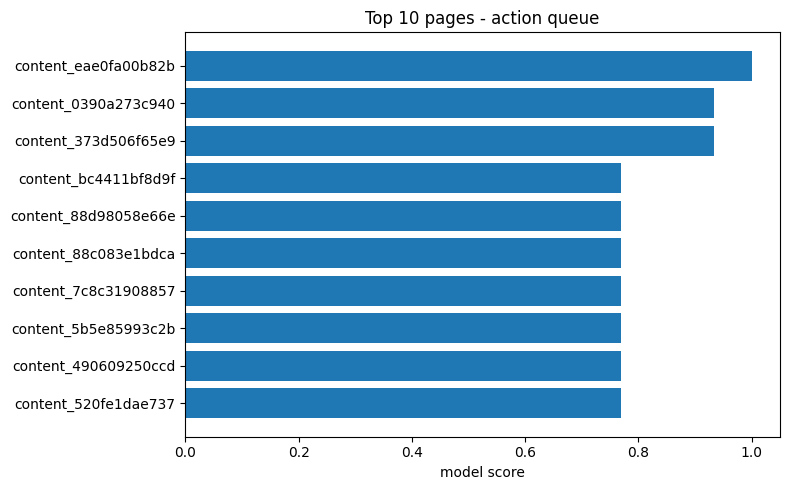

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# the actual queue - stays out of git (CI blocks it), notebook regenerates it every run
ranked_queue.to_csv("work/outputs/baseline_action_score.csv", index=False)

# metrics json - this one DOES get committed, it's basically my receipts
metrics = {
    "model": "Decision Tree (max_depth=5)",
    "split": "client-level holdout, 80/20",
    "precision_at_50_baseline": 0.38,
    "precision_at_50_model": 0.68,
    "rows_in_queue": len(ranked_queue),
    "reason_code_counts": ranked_queue["reason_code"].value_counts().to_dict()
}

with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(metrics)

# quick figure to reuse in the paper later
top10 = ranked_queue.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top10["content_id"], top10["model_score"])
plt.xlabel("model score")
plt.title("Top 10 pages - action queue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("work/figures/w07_top10_scores.png")
plt.show()

Exporting the queue to work/outputs/ (this one's gitignored on purpose, gets
regenerated every time the notebook runs) and a metrics json + a chart that
actually gets committed - those are what next week's paper will pull numbers
and images from instead of me re-running everything again.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.